## Q1

In [1]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm


In [34]:

def varying_greedy(num_runs,num_steps):
    n_rewards=np.zeros(num_steps)
    optimal_action=np.zeros(num_steps)
    error_estimates=np.zeros((10,num_steps))
    for j in tqdm(range(num_runs),total=num_runs):
        # q_a_true=norm.rvs(loc=0,scale=1,size=10)
        q_a_true=np.random.randn(10)
        q_a_est=np.zeros(10)
        n_a=np.zeros(10)
        error_estimates[:,0]=error_estimates[:,0]+abs(q_a_true-q_a_est)
        epsilon=1
        for i in range(1,num_steps):
            if np.random.rand()<epsilon:
                a=np.random.randint(10)
            else:
                a=np.argmax(q_a_est)
            # r=norm.rvs(loc=q_a_true[a],scale=1)
            r=np.random.randn() + q_a_true[a]
            n_rewards[i]=n_rewards[i]+r
            if a==np.argmax(q_a_true):
                optimal_action[i]=optimal_action[i]+1
            n_a[a]+=1
            q_a_est[a]=q_a_est[a]+(r-q_a_est[a])/n_a[a]
            error_estimates[:,i]=error_estimates[:,i]+abs(q_a_true-q_a_est)
            epsilon=1/(i+1)
    optimal_action=optimal_action/num_runs*100
    n_rewards=n_rewards/num_runs
    error_estimates=error_estimates/num_runs
    return (n_rewards,optimal_action,error_estimates)

def epsilon_greedy(num_runs,num_steps,epsilon):
    n_rewards=np.zeros(num_steps)
    optimal_action=np.zeros(num_steps)
    error_estimates=np.zeros((10,num_steps))
    for j in tqdm(range(num_runs),total=num_runs):
        # q_a_true=norm.rvs(loc=0,scale=1,size=10)
        q_a_true=np.random.randn(10)
        q_a_est=np.zeros(10)
        n_a=np.zeros(10)
        error_estimates[:,0]=error_estimates[:,0]+abs(q_a_true-q_a_est)
        for i in range(1,num_steps):
            if np.random.rand()<epsilon:
                a=np.random.randint(10)
            else:
                a=np.argmax(q_a_est)
            # r=norm.rvs(loc=q_a_true[a],scale=1)
            r=np.random.randn() + q_a_true[a]
            n_rewards[i]=n_rewards[i]+r
            if a==np.argmax(q_a_true):
                optimal_action[i]=optimal_action[i]+1
            n_a[a]+=1
            q_a_est[a]=q_a_est[a]+(r-q_a_est[a])/n_a[a]
            error_estimates[:,i]=error_estimates[:,i]+abs(q_a_true-q_a_est)
    optimal_action=optimal_action/num_runs*100
    n_rewards=n_rewards/num_runs
    error_estimates=error_estimates/num_runs
    return (n_rewards,optimal_action,error_estimates)

In [35]:
num_runs=2000
num_steps=1000
rewards_greedy,optimal_actions,error_estimates=epsilon_greedy(num_runs,num_steps,0)
rewards_epsilon,optimal_actions_epsilon,error_estimates_epsilon=epsilon_greedy(num_runs,num_steps,0.1)
rewards_epsilon_2,optimal_actions_epsilon_2,error_estimates_epsilon_2=epsilon_greedy(num_runs,num_steps,0.01)
rewards_epsilon_3,optimal_actions_epsilon_3,error_estimates_epsilon_3=varying_greedy(num_runs,num_steps)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

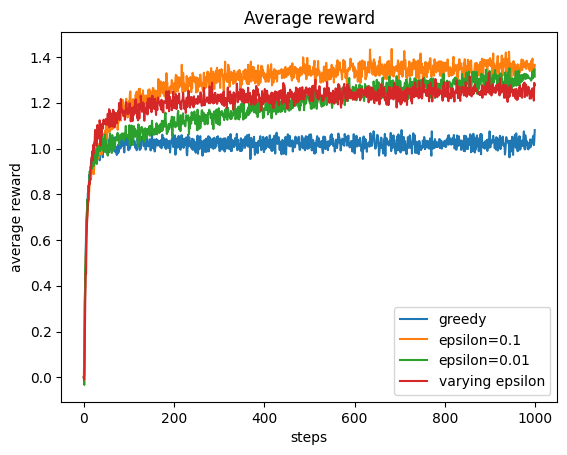

In [36]:
plt.plot(rewards_greedy,label='greedy')
plt.plot(rewards_epsilon,label='epsilon=0.1')
plt.plot(rewards_epsilon_2,label='epsilon=0.01')
plt.plot(rewards_epsilon_3,label='varying epsilon')
plt.title('Average reward')
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()

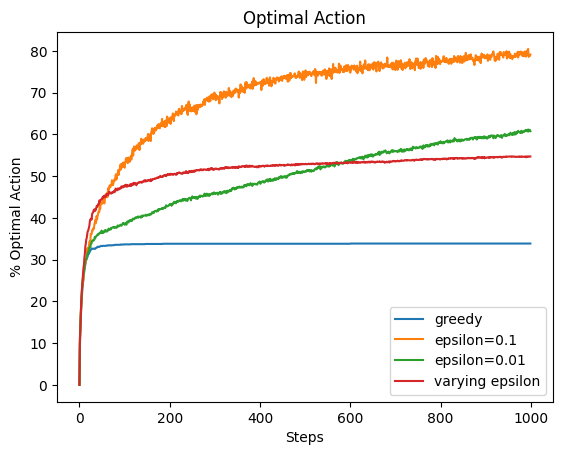

In [37]:
plt.plot(optimal_actions,label='greedy')
plt.plot(optimal_actions_epsilon,label='epsilon=0.1')
plt.plot(optimal_actions_epsilon_2,label='epsilon=0.01')
plt.plot(optimal_actions_epsilon_3,label='varying epsilon')
plt.title('Optimal Action')
plt.xlabel('Steps')
plt.ylabel('% Optimal Action')
plt.legend()

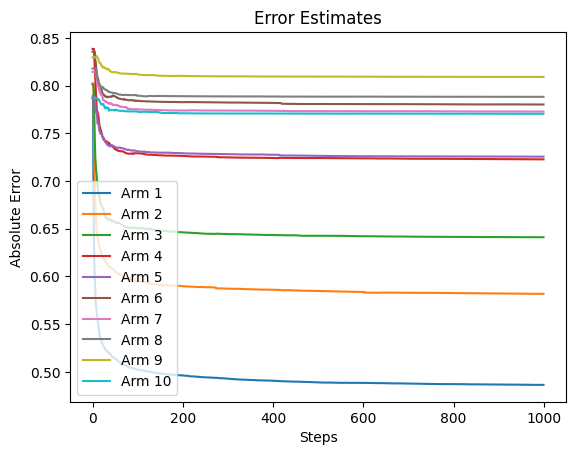

In [38]:
for i, row in enumerate(error_estimates):
    plt.plot(row, label=f'Arm {i + 1}')
plt.title('Error Estimates')
plt.xlabel('Steps')
plt.ylabel('Absolute Error')
plt.legend()

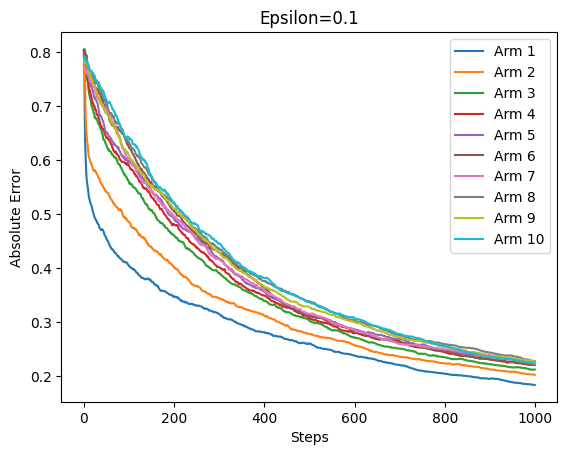

In [39]:
for i, row in enumerate(error_estimates_epsilon):
    plt.plot(row, label=f'Arm {i + 1}')
plt.title('Epsilon=0.1')
plt.xlabel('Steps')
plt.ylabel('Absolute Error')
plt.legend()

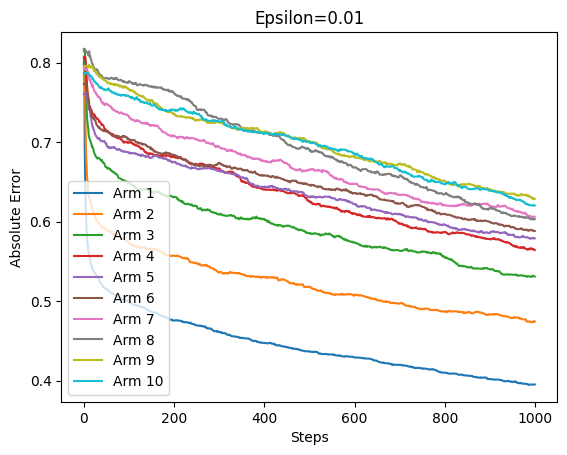

In [40]:
for i, row in enumerate(error_estimates_epsilon_2):
    plt.plot(row, label=f'Arm {i + 1}')
plt.title('Epsilon=0.01')
plt.xlabel('Steps')
plt.ylabel('Absolute Error')
plt.legend()

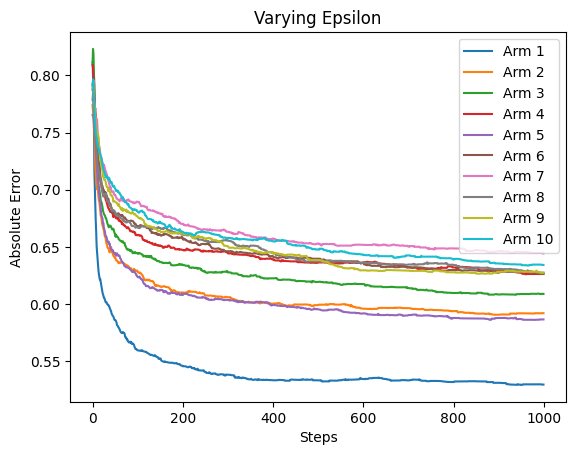

In [41]:
for i, row in enumerate(error_estimates_epsilon_3):
    plt.plot(row, label=f'Arm {i + 1}')
plt.title('Varying Epsilon')
plt.xlabel('Steps')
plt.ylabel('Absolute Error')
plt.legend()

## Q2

In [10]:

def greedy(num_runs,num_steps):
    n_rewards=np.zeros(num_steps)
    optimal_action=np.zeros(num_steps)
    error_estimates=np.zeros((10,num_steps))
    for j in tqdm(range(num_runs),total=num_runs):
        q_a_true=norm.rvs(loc=0,scale=1,size=10)
        q_a_est=np.zeros(10)
        n_a=np.zeros(10)
        error_estimates[:,0]=error_estimates[:,0]+abs(q_a_true-q_a_est)
        for i in range(1,num_steps):
            a=np.argmax(q_a_est)
            r=norm.rvs(loc=q_a_true[a],scale=1)
            n_rewards[i]=n_rewards[i]+r
            if a==np.argmax(q_a_true):
                optimal_action[i]=optimal_action[i]+1
            n_a[a]+=1
            q_a_est[a]=q_a_est[a]+(r-q_a_est[a])/n_a[a]
            error_estimates[:,i]=error_estimates[:,i]+abs(q_a_true-q_a_est)
    optimal_action=optimal_action/num_runs*100
    n_rewards=n_rewards/num_runs
    error_estimates=error_estimates/num_runs
    return (n_rewards,optimal_action,error_estimates)

def epsilon_greedy_2(num_runs,num_steps,epsilon):
    n_rewards=np.zeros(num_steps)
    optimal_action=np.zeros(num_steps)
    error_estimates=np.zeros((10,num_steps))
    for j in tqdm(range(num_runs),total=num_runs):
        # q_a_true=norm.rvs(loc=0,scale=2,size=10)
        q_a_true=np.random.randn(10)
        q_a_est=np.zeros(10)
        n_a=np.zeros(10)
        error_estimates[:,0]=error_estimates[:,0]+abs(q_a_true-q_a_est)
        for i in range(1,num_steps):
            if np.random.rand()<epsilon:
                a=np.random.randint(10)
            else:
                a=np.argmax(q_a_est)
            # r=norm.rvs(loc=q_a_true[a],scale=2)
            r=np.random.randn()*2 + q_a_true[a]
            n_rewards[i]=n_rewards[i]+r
            if a==np.argmax(q_a_true):
                optimal_action[i]=optimal_action[i]+1
            n_a[a]+=1
            q_a_est[a]=q_a_est[a]+(r-q_a_est[a])/n_a[a]
            error_estimates[:,i]=error_estimates[:,i]+abs(q_a_true-q_a_est)
    optimal_action=optimal_action/num_runs*100
    n_rewards=n_rewards/num_runs
    error_estimates=error_estimates/num_runs
    return (n_rewards,optimal_action,error_estimates)

In [11]:
num_runs=2000
num_steps=1000
rewards_greedy,optimal_actions,error_estimates=epsilon_greedy_2(num_runs,num_steps,0)
rewards_epsilon,optimal_actions_epsilon,error_estimates_epsilon=epsilon_greedy_2(num_runs,num_steps,0.1)
rewards_epsilon_2,optimal_actions_epsilon_2,error_estimates_epsilon_2=epsilon_greedy_2(num_runs,num_steps,0.01)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

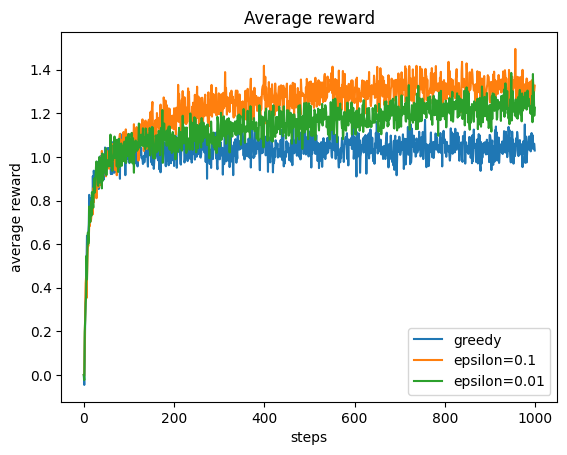

In [12]:
plt.plot(rewards_greedy,label='greedy')
plt.plot(rewards_epsilon,label='epsilon=0.1')
plt.plot(rewards_epsilon_2,label='epsilon=0.01')
plt.title('Average reward')
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()

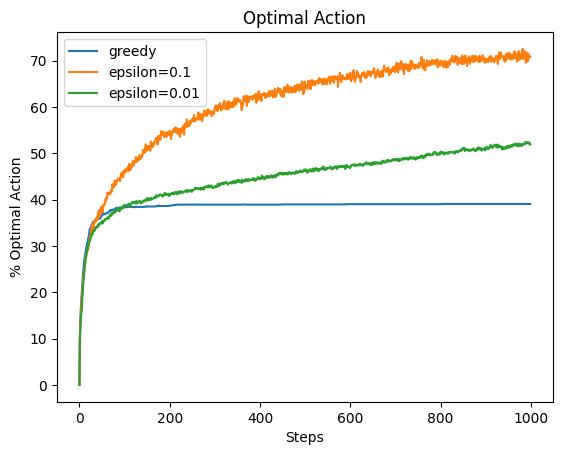

In [13]:
plt.plot(optimal_actions,label='greedy')
plt.plot(optimal_actions_epsilon,label='epsilon=0.1')
plt.plot(optimal_actions_epsilon_2,label='epsilon=0.01')
plt.title('Optimal Action')
plt.xlabel('Steps')
plt.ylabel('% Optimal Action')
plt.legend()

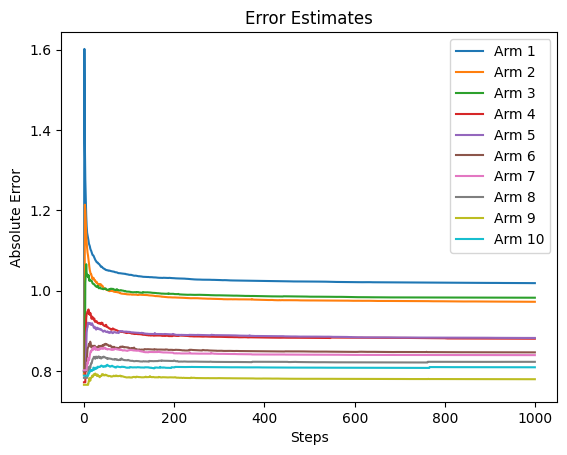

In [14]:
for i, row in enumerate(error_estimates):
    plt.plot(row, label=f'Arm {i + 1}')
plt.title('Error Estimates')
plt.xlabel('Steps')
plt.ylabel('Absolute Error')
plt.legend()

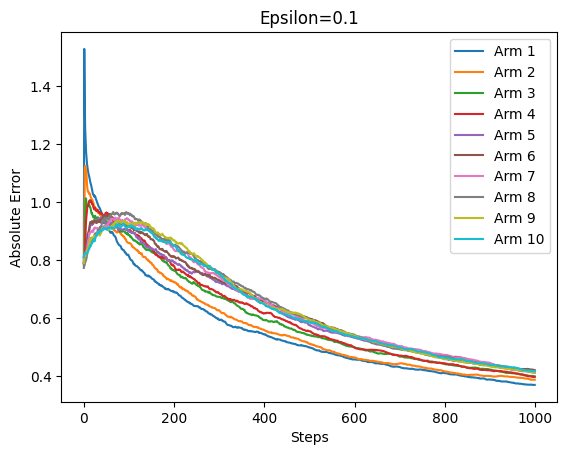

In [15]:
for i, row in enumerate(error_estimates_epsilon):
    plt.plot(row, label=f'Arm {i + 1}')
plt.title('Epsilon=0.1')
plt.xlabel('Steps')
plt.ylabel('Absolute Error')
plt.legend()

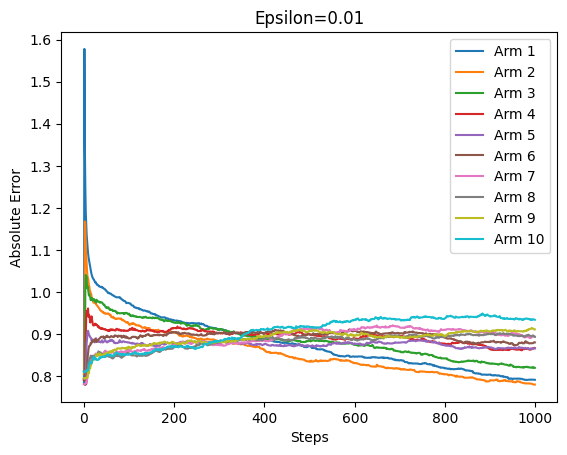

In [16]:
for i, row in enumerate(error_estimates_epsilon_2):
    plt.plot(row, label=f'Arm {i + 1}')
plt.title('Epsilon=0.01')
plt.xlabel('Steps')
plt.ylabel('Absolute Error')
plt.legend()

## Q5

In [17]:
def modified_greedy(num_runs,num_steps,epsilon,alpha):
    n_rewards=np.zeros(num_steps)
    optimal_action=np.zeros(num_steps)
    error_estimates=np.zeros((10,num_steps))
    for j in tqdm(range(num_runs),total=num_runs):
        # q_a_true=norm.rvs(loc=0,scale=2,size=10)
        q_a_true=np.zeros(10)
        q_a_est=np.zeros(10)
        n_a=np.zeros(10)
        error_estimates[:,0]=error_estimates[:,0]+abs(q_a_true-q_a_est)
        for i in range(1,num_steps):
            q_a_true=q_a_true+np.random.randn(10)*0.01
            if np.random.rand()<epsilon:
                a=np.random.randint(10)
            else:
                a=np.argmax(q_a_est)
            # r=norm.rvs(loc=q_a_true[a],scale=2)
            r=np.random.randn() + q_a_true[a]
            n_rewards[i]=n_rewards[i]+r
            if a==np.argmax(q_a_true):
                optimal_action[i]=optimal_action[i]+1
            n_a[a]+=1
            if not alpha:
                q_a_est[a]=q_a_est[a]+(r-q_a_est[a])/n_a[a]
            else:
                q_a_est[a]=q_a_est[a]+alpha*(r-q_a_est[a])
            error_estimates[:,i]=error_estimates[:,i]+abs(q_a_true-q_a_est)
            
    optimal_action=optimal_action/num_runs*100
    n_rewards=n_rewards/num_runs
    error_estimates=error_estimates/num_runs
    return (n_rewards,optimal_action,error_estimates)

In [18]:
num_runs=1000
num_steps=10000
rewards_greedy,optimal_actions,error_estimates=modified_greedy(num_runs,num_steps,0.1,None)
rewards_epsilon,optimal_actions_epsilon,error_estimates_epsilon=modified_greedy(num_runs,num_steps,0.1,0.1)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

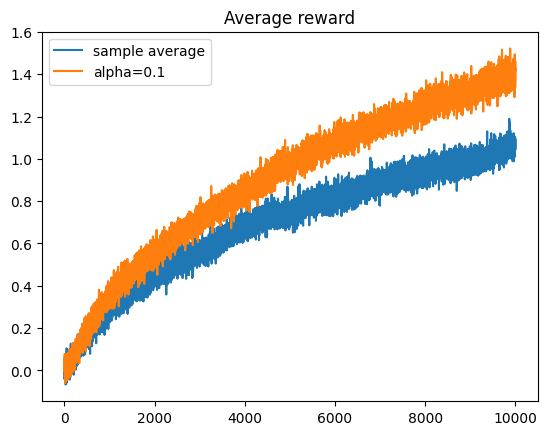

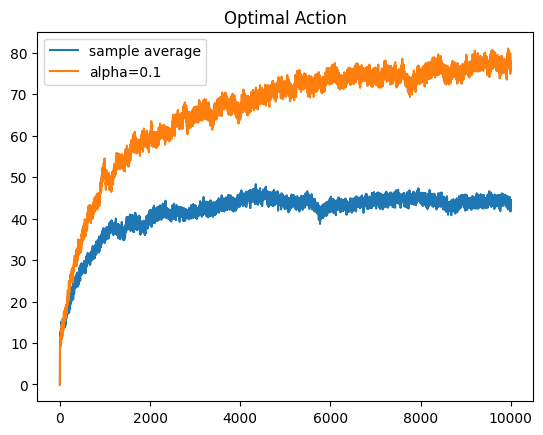

In [19]:
plt.plot(rewards_greedy,label='sample average')
plt.plot(rewards_epsilon,label='alpha=0.1')
plt.title('Average reward')
plt.legend()
plt.show()
plt.plot(optimal_actions,label='sample average')
plt.plot(optimal_actions_epsilon,label='alpha=0.1')
plt.title('Optimal Action')
plt.legend()


## Q6

In [20]:
def ucb(num_runs,num_steps,c):
    n_rewards=np.zeros(num_steps)
    optimal_action=np.zeros(num_steps)
    error_estimates=np.zeros((10,num_steps))
    for j in tqdm(range(num_runs),total=num_runs):
        # q_a_true=norm.rvs(loc=0,scale=1,size=10)
        q_a_true=np.random.randn(10)
        q_a_est=np.zeros(10)
        n_a=np.zeros(10)+1e-7
        error_estimates[:,0]=error_estimates[:,0]+abs(q_a_true-q_a_est)
        for i in range(1,num_steps):
            a=np.argmax(q_a_est+c*np.sqrt(np.log(i)/n_a))
            # r=norm.rvs(loc=q_a_true[a],scale=1)
            r=np.random.randn() + q_a_true[a]
            n_rewards[i]=n_rewards[i]+r
            if a==np.argmax(q_a_true):
                optimal_action[i]=optimal_action[i]+1
            n_a[a]+=1
            q_a_est[a]=q_a_est[a]+(r-q_a_est[a])/n_a[a]
            error_estimates[:,i]=error_estimates[:,i]+abs(q_a_true-q_a_est)
    optimal_action=optimal_action/num_runs*100
    n_rewards=n_rewards/num_runs
    error_estimates=error_estimates/num_runs
    return (n_rewards,optimal_action,error_estimates)


In [21]:
num_runs=2000
num_steps=1000
rewards_ucb,optimal_actions,error_estimates=ucb(num_runs,num_steps,2)
rewards_ucb_2,optimal_actions_2,error_estimates_2=ucb(num_runs,num_steps,1)
rewards_ucb_3,optimal_actions_3,error_estimates_3=ucb(num_runs,num_steps,4)
rewards_epsilon,optimal_actions_epsilon,error_estimates_epsilon=epsilon_greedy(num_runs,num_steps,0.1)


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

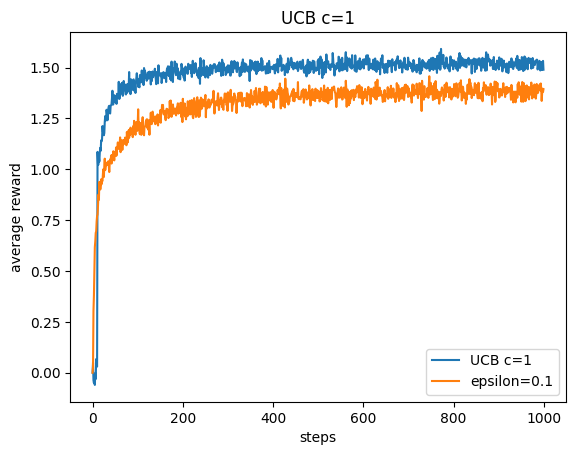

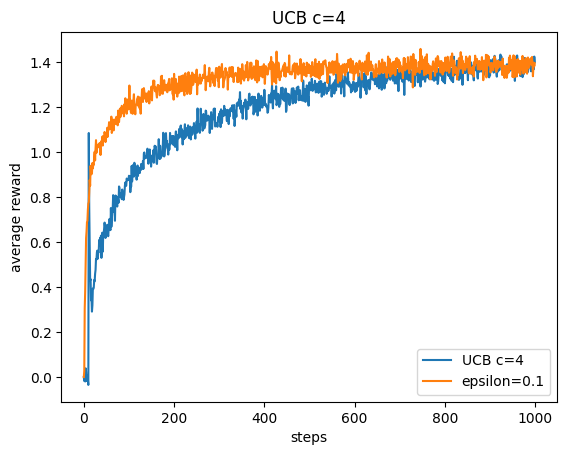

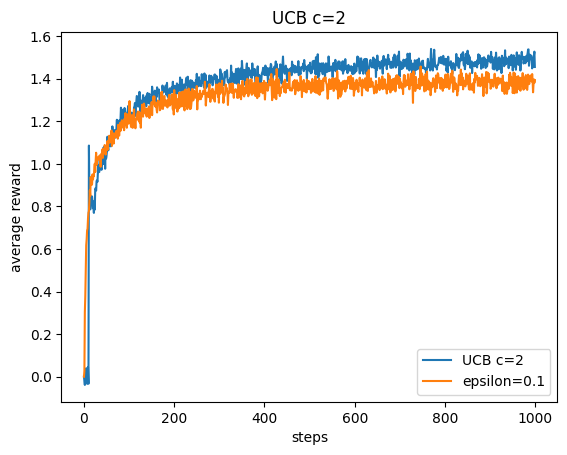

In [22]:
plt.plot(rewards_ucb_2,label='UCB c=1')
plt.plot(rewards_epsilon,label='epsilon=0.1')
plt.title('UCB c=1')
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()
plt.show()

plt.plot(rewards_ucb_3,label='UCB c=4')
plt.plot(rewards_epsilon,label='epsilon=0.1')
plt.title('UCB c=4')
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()
plt.show()

plt.plot(rewards_ucb,label='UCB c=2')
plt.plot(rewards_epsilon,label='epsilon=0.1')
plt.title('UCB c=2')
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()


## Q7

In [23]:
def gradient_bandit(num_runs,num_steps,alpha):
    optimal_action=np.zeros(num_steps)

    for j in tqdm(range(num_runs),total=num_runs):
        # q_a_true=norm.rvs(loc=0,scale=1,size=10)
        q_a_true=np.random.randn(10)
        q_a_est=np.zeros(10)
        n_a=np.zeros(10)
        H=np.zeros(10)
        n_rewards=np.zeros(num_steps)

        for i in range(1,num_steps):
            p=np.exp(H)
            p=p/np.sum(p)
            a=np.random.choice(10,p=p)
            # r=norm.rvs(loc=q_a_true[a],scale=1)
            r=np.random.randn() + q_a_true[a]
            n_rewards[i]=n_rewards[i]+r
            if a==np.argmax(q_a_true):
                optimal_action[i]=optimal_action[i]+1
            n_a[a]+=1
            q_a_est[a]=q_a_est[a]+(r-q_a_est[a])/n_a[a]

            avg_reward=np.sum(n_rewards)/i
            H=H-alpha*(r-avg_reward)*(p)
            H[a]=H[a]+alpha*(r-avg_reward)

    optimal_action=optimal_action/num_runs*100
    return optimal_action

def gradient_bandit_without_baseline(num_runs,num_steps,alpha):
    
    optimal_action=np.zeros(num_steps)
    
    for j in tqdm(range(num_runs),total=num_runs):
        n_rewards=np.zeros(num_steps)
        # q_a_true=norm.rvs(loc=4,scale=1,size=10)
        q_a_true=np.random.randn(10)+4
        q_a_est=np.zeros(10)
        n_a=np.zeros(10)
        H=np.zeros(10)

        for i in range(1,num_steps):
            p=np.exp(H)
            p=p/np.sum(p)
            a=np.random.choice(10,p=p)
            # r=norm.rvs(loc=q_a_true[a],scale=1)
            r=np.random.randn() + q_a_true[a]
            n_rewards[i]=n_rewards[i]+r
            if a==np.argmax(q_a_true):
                optimal_action[i]=optimal_action[i]+1
            n_a[a]+=1
            q_a_est[a]=q_a_est[a]+(r-q_a_est[a])/n_a[a]

            H=H-alpha*(r)*(p)
            H[a]=H[a]+alpha*(r)
            
    optimal_action=optimal_action/num_runs*100
    return optimal_action

In [24]:
num_runs=2000
num_steps=1000
optimal_actions=gradient_bandit(num_runs,num_steps,0.1)
optimal_actions_2=gradient_bandit(num_runs,num_steps,0.4)
optimal_actions_without_baseline=gradient_bandit_without_baseline(num_runs,num_steps,0.1)
optimal_actions_without_baseline_2=gradient_bandit_without_baseline(num_runs,num_steps,0.4)


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

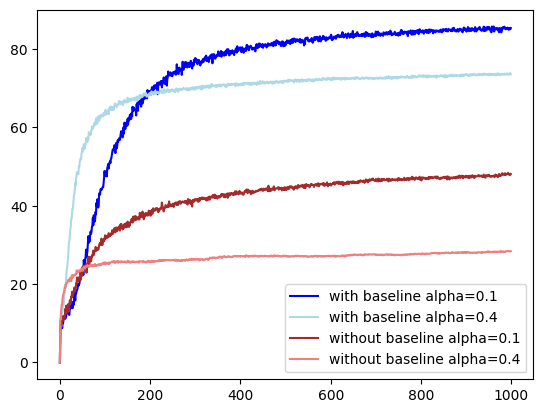

In [25]:
plt.plot(optimal_actions,label='with baseline alpha=0.1',color='blue')
plt.plot(optimal_actions_2,label='with baseline alpha=0.4',color='lightblue')
plt.plot(optimal_actions_without_baseline,label='without baseline alpha=0.1',color='brown')
plt.plot(optimal_actions_without_baseline_2,label='without baseline alpha=0.4',color='lightcoral')
plt.legend()